# Notebook 01 — Lending Club Survival Data Preparation

Prepares ~2.25 million Lending Club accepted loans (2007–2018 Q4) for survival analysis.
Outputs  used by all subsequent notebooks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 100)

## Load Data

In [2]:
path = '../data/accepted_2007_to_2018Q4.csv.gz'
df = pd.read_csv(path, compression='gzip', low_memory=False)
df.shape

(2247571, 13)

## Select Relevant Columns

In [3]:
cols = ['loan_status','issue_d','last_pymnt_d','term','annual_inc','emp_length','int_rate','loan_amnt','dti','grade','home_ownership']
df = df[cols]
df.head()

,loan_status,issue_d,last_pymnt_d,term,annual_inc,emp_length,int_rate,loan_amnt,dti,grade,home_ownership
0,Fully Paid,2015-12-01,2019-01-01,36 months,55000.0,10+ years,13.99,3600.0,5.91,C,MORTGAGE
1,Fully Paid,2015-12-01,2016-06-01,36 months,65000.0,10+ years,11.99,24700.0,16.06,C,MORTGAGE
2,Fully Paid,2015-12-01,2017-06-01,60 months,63000.0,10+ years,10.78,20000.0,10.78,B,MORTGAGE
3,Current,2015-12-01,2019-02-01,60 months,110000.0,10+ years,14.85,35000.0,17.06,C,MORTGAGE
4,Fully Paid,2015-12-01,2016-07-01,60 months,104433.0,3 years,22.45,10400.0,25.37,F,MORTGAGE


## Fix Data Types

In [5]:
# ensure int_rate is numeric (handles strings like '13.99%' and numeric values)
df['int_rate'] = pd.to_numeric(df['int_rate'].astype(str).str.rstrip('%'), errors='coerce')

# extract numeric term (e.g. '36 months') and store as nullable integer
df['term'] = pd.to_numeric(df['term'].astype(str).str.extract(r'(\d+)')[0], errors='coerce').astype('Int64')

## Parse Dates and Drop Missing

In [8]:
# parse dates — ISO format (2015-12-01) and legacy format (Dec-2015) are both handled automatically
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
df['last_pymnt_d'] = pd.to_datetime(df['last_pymnt_d'], errors='coerce')
df = df.dropna(subset=['issue_d','last_pymnt_d'])

## Default Indicator

In [9]:
default_status = ['Charged Off','Default','Late (31-120 days)']
df['event'] = df['loan_status'].isin(default_status).astype(int)
df['event'].value_counts(normalize=True)

event
0    0.872064
1    0.127936
Name: proportion, dtype: float64

## Observed Time (Months)

In [10]:
df['time'] = (df['last_pymnt_d'] - df['issue_d']).dt.days / 30.0
df = df[df['time'] > 0]
df[['time','event']].head()

,time,event
0,37.566667,0
1,6.100000,0
2,18.266667,0
3,38.600000,0
4,7.100000,0


## Drop Remaining NaNs

In [11]:
df = df.dropna(subset=['time','annual_inc','dti','loan_amnt','int_rate'])
df.shape

(2247571, 13)

## Empirical Survival Curve

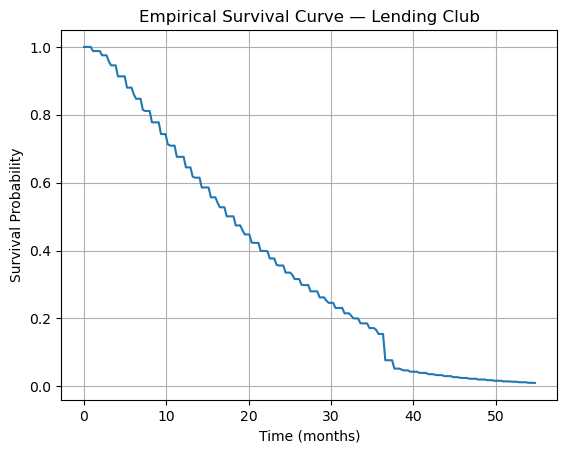

In [12]:
times = np.linspace(0, df['time'].quantile(0.99), 200)
survival = [(df['time'] > t).mean() for t in times]
plt.plot(times, survival)
plt.xlabel('Time (months)')
plt.ylabel('Survival Probability')
plt.title('Empirical Survival Curve — Lending Club')
plt.grid(True)
plt.show()

## Save Clean Dataset

In [13]:
df.to_csv('../data/lendingclub_survival_clean.csv', index=False)
print('Saved lendingclub_survival_clean.csv')

Saved lendingclub_survival_clean.csv
